# Summary statistics, embeddings, SNPE y diagnosticos con `sbi`

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorobledo/apbf/blob/main/APBF/teorico_practicos/Semana06_sbi_03.ipynb)

Ya vimos que, en el flujo de trabajo de `sbi`, necesitamos un simulador que genere datos $x$ a partir de parametros $\theta$, junto con una prior desde la cual podamos muestrear muchos valores de esos parametros. Con los pares $(\theta_i, x_i)$ entrenamos luego un modelo para aproximar la posterior condicional $p(\theta \mid x)$.

El desafio aparece cuando la salida del simulador tiene dimension alta. Eso ocurre, por ejemplo, con imagenes, campos espaciales o trayectorias temporales largas. En esos casos conviene comprimir la informacion antes de hacer inferencia.

En esta notebook vamos a recorrer cuatro ideas importantes de inferencia basada en simulaciones:

- construir **summary statistics** a mano;
- **aprender summary statistics con embeddings**;
- usar **SNPE** en rondas secuenciales;
- diagnosticar la posterior con **PPCs**, **expected coverage** y **simulation-based calibration (SBC)**.

La logica general sera:

1. cargar una trayectoria observada de un sistema fisico;
2. definir un resumen de esa trayectoria;
3. entrenar una posterior amortizada con `NPE` sobre esos resumenes;
4. comparar ese enfoque con un embedding aprendido;
5. refinar la inferencia con `SNPE`, pero trabajando directamente con las summary statistics;
6. chequear la calidad de la posterior con diagnosticos de calibracion.

## Parte 1

### Un simulador de dinamica molecular

En este ejemplo trabajaremos con un simulador unidimensional de dinamica molecular. El sistema contiene cuatro atomos de argon que interactuan mediante fuerzas derivadas de un potencial. Una de las descripciones mas simples para esta interaccion es el potencial de [Lennard-Jones](https://es.wikipedia.org/wiki/Potencial_de_Lennard-Jones), que combina una parte repulsiva y una parte atractiva:

$$
V(r) = 4 \epsilon\left[\left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6\right].
$$

Si tomamos la fuerza como el gradiente negativo de la energia potencial, obtenemos
$$
\|\vec{F}(r)\| = 48 \epsilon  \sigma^{12} / r^{13} - 24  \epsilon  \sigma^{6}/r^7,
$$
donde omitimos la direccion vectorial, que coincide con la recta que une a las particulas que interactuan. Como tenemos una expresion analitica para la fuerza, podemos usar las leyes de Newton para obtener aceleracion, velocidad y posicion en cada instante, una vez fijadas las condiciones iniciales.

El simulador que resuelve estas ecuaciones esta implementado en `md.py`. Antes de usarlo conviene mirar su interfaz, porque eso deja claro que insumos necesita y que devuelve.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
%matplotlib inline

import os
import pickle
from pathlib import Path

from scipy.signal import find_peaks

from sbi.inference import NPE, SNPE, simulate_for_sbi
from sbi.analysis import pairplot
from sbi.analysis.plot import sbc_rank_plot
from sbi.diagnostics import check_sbc, run_sbc
from sbi.neural_nets import posterior_nn
from sbi.utils import BoxUniform
from sbi.utils.user_input_checks import process_prior, process_simulator
from sbi.utils.sbiutils import seed_all_backends

from md import run_md

DATA_PATH = Path("observation_free.pkl")
seed_all_backends(24)

num_cpus = os.cpu_count() or 1
workers = max(1, min(8, num_cpus - 1))
print(f"Se encontraron {num_cpus} nucleos. Se usaran {workers} workers.")

/Users/robledo/.virtualenvs/sbi/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Se encontraron 8 nucleos. Se usaran 7 workers.


Veamos ahora la interfaz del simulador para identificar que informacion recibe y que trayectoria devuelve.

In [2]:
print(run_md.__doc__)


    Run a molecular dynamics (MD) simulation using the velocity Verlet algorithm.

    Parameters
    ----------
    dt : float
        The timestep length (s).
    number_of_steps : int
        Number of iterations in the simulation.
    x : ndarray of floats
        The initial positions of the particles in a single dimension (Å).
    initial_temp : float
        Temperature of the system at initialization (K).
    epsilon : float
        Depth of the potential well in the Lennard-Jones potential (energy units).
    sigma : float
        Finite distance at which the inter-particle potential is zero (Å).
    box_length : float, optional, default=20
        Length of the simulation box (Å).
    seed : int, optional, default=None
        Random seed for reproducibility.

    Returns
    -------
    positions : ndarray of floats
        The positions of all particles at each timestep of the simulation (Å).
        Shape: (number_of_steps, num_particles).
    


Una simulacion queda completamente determinada cuando fijamos:

- la temperatura inicial $T$ del sistema;
- los parametros del potencial de Lennard-Jones $\epsilon$ y $\sigma$;
- las posiciones iniciales $\vec{x_0}$ de los atomos;
- el paso temporal $dt$ y la cantidad de pasos de integracion.

En esta notebook tomaremos como parametro desconocido
$$
\theta = (T, \epsilon, \sigma),
$$
mientras que las posiciones iniciales y la geometria de la caja se consideran observadas.

## Parte 2

### Datos observados

Supongamos ahora que medimos las trayectorias de los cuatro atomos en una caja de longitud 20 durante toda una ventana temporal. Cargamos esos datos observados y los graficamos.

In [3]:
with DATA_PATH.open("rb") as pf:
    t, x_truth = pickle.load(pf)

Datos observados: 4000 tiempos x 4 atomos


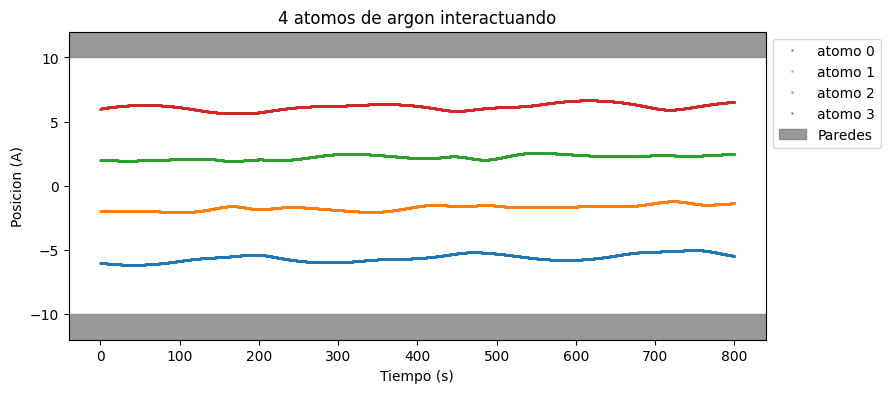

In [4]:
# Conocemos la longitud de la caja
box_length = 20

print(f"Datos observados: {x_truth.shape[0]} tiempos x {x_truth.shape[1]} atomos")

fig, ax = plt.subplots(figsize=(9, 4))
for i in range(x_truth.shape[1]):
    ax.plot(t, x_truth[:, i], "o", ms=1, label=f"atomo {i}", alpha=0.5)
ax.set_ylim(-box_length * 0.6, box_length * 0.6)
ax.axhspan(box_length / 2, ax.get_ylim()[1], color="gray", alpha=0.8, label="Paredes")
ax.axhspan(ax.get_ylim()[0], -box_length / 2, color="gray", alpha=0.8)
ax.legend(bbox_to_anchor=(1, 1))
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Posicion (A)")
ax.set_title("4 atomos de argon interactuando")
plt.show()

Las trayectorias contienen informacion sobre el potencial que sienten las particulas. Como las posiciones iniciales fueron medidas, podemos tratarlas como cantidades fijas. Lo que no conocemos son los parametros del potencial y la temperatura del sistema, que son justamente las cantidades que queremos inferir.

Antes de empezar con `sbi`, conviene construir una simulacion de prueba para ver como se relacionan los parametros fisicos con la forma de las trayectorias.

In [5]:
# Extraemos las posiciones iniciales
x0 = x_truth[0, :].copy()

# Calculamos el paso temporal
dt = t[1] - t[0]

print("Posiciones iniciales medidas:", x0)
print(f"Paso temporal dt = {dt:.3f} s")

Posiciones iniciales medidas: [-6.00148456 -1.99962368  1.99962237  6.00203543]
Paso temporal dt = 0.200 s


Recordemos que la temperatura se mide en Kelvin, mientras que $\epsilon$ y $\sigma$ estan en escalas compatibles con distancias y energias atomicas. El orden de los parametros en $\theta$ sera siempre $(T, \epsilon, \sigma)$.

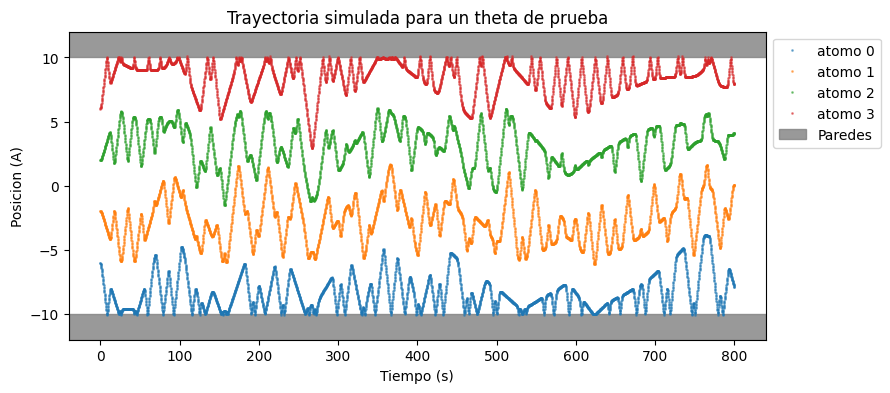

In [6]:
def unpack_theta(theta):
    theta = torch.as_tensor(theta, dtype=torch.float32).detach().cpu().numpy()
    return theta


def create_x(theta):
    T, epsilon, sigma = unpack_theta(theta)
    return run_md(dt, len(t), x0.copy(), T, epsilon, sigma, box_length=box_length)

def plot_single(theta):
    x = create_x(theta)
    fig, ax = plt.subplots(figsize=(9, 4))
    for i in range(x_truth.shape[1]):
        ax.plot(t, x[:, i], "o", ms=1, label=f"atomo {i}", alpha=0.5)
    ax.set_ylim(-box_length * 0.6, box_length * 0.6)
    ax.axhspan(box_length / 2, ax.get_ylim()[1], color="gray", alpha=0.8, label="Paredes")
    ax.axhspan(ax.get_ylim()[0], -box_length / 2, color="gray", alpha=0.8)
    ax.legend(bbox_to_anchor=(1, 1))
    ax.set_xlabel("Tiempo (s)")
    ax.set_ylabel("Posicion (A)")
    ax.set_title("Trayectoria simulada para un theta de prueba")
    plt.show()


T = 100.0  # Kelvin
epsilon = 0.1  # eV / A
sigma = 5.0  # A

theta_test = torch.tensor([T, epsilon, sigma], dtype=torch.float32)
plot_single(theta_test)

## Parte 3

### Introduccion a las summary statistics

Si quisieramos seguir el flujo de trabajo de `sbi` usando las trayectorias completas como entrada, la red tendria que procesar un volumen grande de informacion. Eso implicaria entradas de alta dimension, modelos mas grandes y entrenamiento mas costoso.

La alternativa es construir **summary statistics**, es decir, cantidades mas compactas que conserven informacion relevante de las trayectorias. En este problema, una inspeccion visual sugiere varias opciones utiles:

- distancias promedio entre pares de atomos: con 4 atomos hay $(4 \times 3)/2 = 6$ distancias posibles;
- una energia cinetica promedio, obtenida a partir de velocidades aproximadas;
- la cantidad de picos en cada trayectoria, como una medida simple del grado de oscilacion.

Estas cantidades no son magicas: son una hipotesis de trabajo. La idea es comprimir la trayectoria sin perder demasiada informacion sobre $\theta$.

En total construiremos un vector resumen de dimension 11. Eso reduce mucho la entrada respecto de usar la trayectoria completa, y ademas nos obliga a pensar que rasgos del sistema son fisicamente informativos.

In [ ]:
summary_labels = [
    "dist_01",
    "dist_02",
    "dist_03",
    "dist_12",
    "dist_13",
    "dist_23",
    "picos_0",
    "picos_1",
    "picos_2",
    "picos_3",
    "energia_media",
]


def pairwise_distances(x):
    """Calcula las distancias entre todos los pares de atomos a lo largo del tiempo."""
    n = x.shape[1]
    i, j = np.triu_indices(n, k=1)
    return np.abs(x[:, i] - x[:, j])


def calculate_average_energy(dt, x):
    """Aproxima la energia cinetica media a partir de diferencias finitas."""
    v = np.diff(x, axis=0) / dt
    ke = 0.5 * np.sum(v**2, axis=1)
    return np.mean(ke)


def summary_from_trajectory(x, epsilon=None):
    """Resume una trayectoria en 11 cantidades informativas."""
    avg_pairwise_distance = pairwise_distances(x).mean(axis=0)
    num_peaks = np.array(
        [len(find_peaks(component)[0]) for component in ((x - x.mean(axis=0)) ** 2).T]
    )
    average_energy = np.array([calculate_average_energy(dt, x)])
    return np.concatenate([avg_pairwise_distance, num_peaks, average_energy]).astype(np.float32)


def create_summary(theta):
    x = create_x(theta)
    return summary_from_trajectory(x)

Probemos estas summary statistics sobre el valor de prueba $\theta$ que acabamos de usar. Asi vemos tanto los valores numericos como la dimension final del resumen.

In [8]:
summary_test = create_summary(theta_test)
for label, value in zip(summary_labels, summary_test):
    print(f"{label:>14s}: {value:.4f}")
print()
print(f"Dimension del resumen: {summary_test.size}")

       dist_01: 5.5573
       dist_02: 11.4270
       dist_03: 16.9929
       dist_12: 5.8697
       dist_13: 11.4356
       dist_23: 5.5659
       picos_0: 100.0000
       picos_1: 82.0000
       picos_2: 82.0000
       picos_3: 93.0000
 energia_media: 0.2675

Dimension del resumen: 11


## Parte 4

### Definir la prior y preparar el simulador

Para comenzar el flujo de trabajo de `sbi`, definimos una prior razonable sobre los tres parametros que queremos inferir. La prior fija la region del espacio de parametros que estamos dispuestos a explorar con simulaciones.

In [9]:
parameter_labels = ["T", "epsilon", "sigma"]
prior_min = torch.as_tensor([1e-3, 0.005, 1.6])
prior_max = torch.as_tensor([2000.0, 0.05, 5.0])
prior = BoxUniform(low=prior_min, high=prior_max)

for name, low, high in zip(parameter_labels, prior_min, prior_max):
    print(f"Prior {name}: [{float(low):.4g}, {float(high):.4g}]")

Prior T: [0.001, 2000]
Prior epsilon: [0.005, 0.05]
Prior sigma: [1.6, 5]


Tambien elegimos automaticamente el dispositivo de computo disponible. En CPU usaremos multiprocesamiento para las simulaciones; si hay GPU, la aprovecharemos sobre todo durante el entrenamiento de la red neuronal.

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo de entrenamiento: {device}")

Dispositivo de entrenamiento: cpu


Luego verificamos la prior y adaptamos el simulador al formato esperado por `sbi`. Ese paso es importante porque `sbi` necesita una funcion que reciba parametros y devuelva observaciones en un formato consistente.

In [17]:
# Tamano de los distintos conjuntos que usaremos en la notebook
n_traj_simulations = 2000
n_summary_simulations = 2000
n_round2_simulations = 1000
num_posterior_draws = 5000
num_ppc_samples = 200
num_diag_samples = 150
num_posterior_samples_diag = 300

# Simulamos en CPU usando multiples nucleos
prior.to("cpu")
prior, num_parameters, prior_returns_numpy = process_prior(prior)
simulate_x = process_simulator(create_x, prior, prior_returns_numpy)

print(f"Numero de parametros inferidos: {num_parameters}")

Numero de parametros inferidos: 3


Con todo eso listo, generamos dos conjuntos de simulaciones:

- un conjunto moderado de trayectorias completas, que reutilizaremos mas adelante en la seccion de embeddings;
- un conjunto mas grande de summary statistics, que usaremos para entrenar la posterior amortizada basada en resumenes.

Este paso puede tomar tiempo y es un buen ejemplo de por que el acceso a computo paralelo o HPC resulta util en inferencia basada en simulaciones.

In [14]:
%%time
theta_traj, x_traj = simulate_for_sbi(
    simulate_x,
    prior,
    num_simulations=n_traj_simulations,
    num_workers=workers,
)
print(theta_traj.shape, x_traj.shape)

100%|██████████| 2000/2000 [01:09<00:00, 28.94it/s]

torch.Size([2000, 3]) torch.Size([2000, 4000, 4])
CPU times: user 9.44 s, sys: 518 ms, total: 9.96 s
Wall time: 1min 9s


Despues de simular, podemos visualizar algunas trayectorias generadas. Como la prior es amplia, aparecen dinamicas muy distintas. Ese conjunto de trayectorias completas tambien nos servira luego para aprender embeddings.

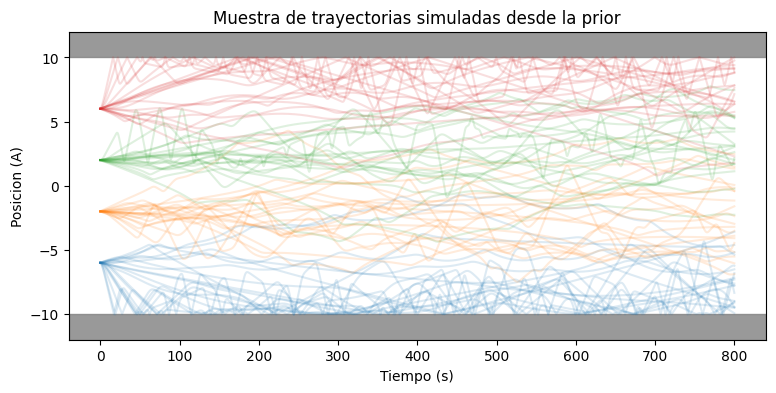

In [15]:
rng = np.random.default_rng(24)
fig, ax = plt.subplots(figsize=(9, 4))
for i, ci in zip(range(x_traj.shape[2]), mcolors.TABLEAU_COLORS):
    sample_ids = rng.choice(x_traj.shape[0], size=20, replace=False)
    for idx in sample_ids:
        ax.plot(t, x_traj[idx, :, i], color=ci, alpha=0.15)
ax.set_ylim(-box_length * 0.6, box_length * 0.6)
ax.axhspan(box_length / 2, ax.get_ylim()[1], color="gray", alpha=0.8)
ax.axhspan(ax.get_ylim()[0], -box_length / 2, color="gray", alpha=0.8)
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Posicion (A)")
ax.set_title("Muestra de trayectorias simuladas desde la prior")
plt.show()

## Parte 5

### Entrenar `sbi` usando summary statistics

Para usar `sbi` con summary statistics, necesitamos transformar cada trayectoria simulada en su vector resumido correspondiente. Una forma de hacerlo es aplicar `create_summary` a cada trayectoria; otra, mas conveniente, es envolver directamente esa funcion con `process_simulator`.

El resultado es un nuevo simulador que ya no devuelve trayectorias crudas sino vectores resumen. Sobre esos pares $(	heta, x_{summary})$ entrenaremos una posterior amortizada con `NPE`.

In [18]:
simulate_summary = process_simulator(create_summary, prior, prior_returns_numpy)

In [19]:
%%time
theta, x_summary = simulate_for_sbi(
    simulate_summary,
    prior,
    num_simulations=n_summary_simulations,
    num_workers=workers,
)
print(theta.shape, x_summary.shape)

100%|██████████| 2000/2000 [01:07<00:00, 29.74it/s]

torch.Size([2000, 3]) torch.Size([2000, 11])
CPU times: user 13.1 s, sys: 609 ms, total: 13.7 s
Wall time: 1min 7s


Ahora que ya tenemos pares del tipo $(\theta, x_{summary})$, entrenamos una red neuronal para aprender la posterior condicional $p(\theta \mid x_{summary})$.

Como este modelo es **amortizado**, una vez entrenado podremos evaluar la posterior para cualquier nueva observacion, siempre que primero la resumamos con la misma funcion `summary_from_trajectory`.

In [50]:
train_kwargs = dict(
    training_batch_size=1024,
    learning_rate=5e-4,
    stop_after_epochs=40,
    max_num_epochs=400,
    validation_fraction=0.15,
    show_train_summary=True,
)
train_kwargs

{'training_batch_size': 1024,
 'learning_rate': 0.0005,
 'stop_after_epochs': 20,
 'max_num_epochs': 400,
 'validation_fraction': 0.15,
 'show_train_summary': True}

Usaremos un normalizing flow tipo zuko_maf para aproximar $p(\theta | x_{summary})$.

In [74]:
density_estimator = posterior_nn(
    "zuko_maf",
    hidden_features=100,
    num_transforms=10,
    z_score_theta="independent",
    z_score_x="independent",
)

In [75]:
# Entrenamos la red neuronal sobre summary statistics
prior.to(device)
inference = NPE(prior=prior, device=device, density_estimator=density_estimator)
density_estimator = inference.append_simulations(
    theta.to(device),
    x_summary.to(device),
    proposal=prior,
    exclude_invalid_x=True,
).train(**train_kwargs)

 Neural network successfully converged after 255 epochs.
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 255
        Best validation performance: 4.3910
        -------------------------
        


In [76]:
summary = inference.summary

In [77]:
print(list(summary.keys()))

['epochs_trained', 'best_validation_loss', 'validation_loss', 'training_loss', 'epoch_durations_sec']


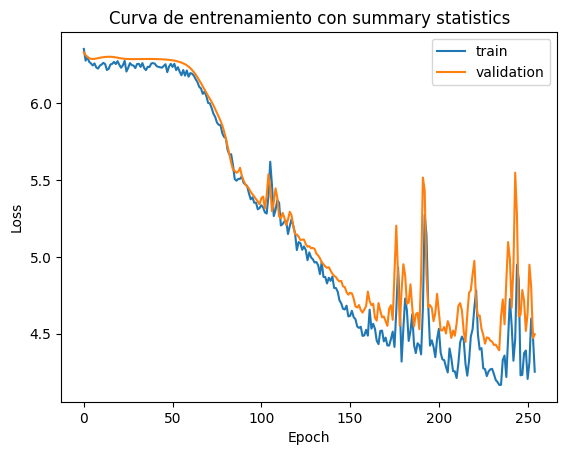

In [78]:
plt.plot(summary["training_loss"], label="train")
plt.plot(summary["validation_loss"], label="validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Curva de entrenamiento con summary statistics")
plt.show()

Si hay GPU disponible, podemos entrenar alli y luego mover el modelo a CPU para hacer inferencia. Como el muestreo posterior no es demasiado costoso, este cambio suele ser conveniente.

In [79]:
inference._neural_net.to("cpu")
prior.to("cpu")
posterior = inference.build_posterior(prior=prior)

Calculamos ahora las summary statistics del dato observado. Este paso es clave: la observacion real debe pasar exactamente por la misma transformacion que usamos para las simulaciones.

In [83]:
# Generamos las summary statistics del dato observado
x_summary_o = torch.as_tensor(summary_from_trajectory(x_truth), dtype=torch.float32)
for label, value in zip(summary_labels, x_summary_o):
    print(f"{label:>14s}: {float(value):.4f}")

theta_p = posterior.sample((num_posterior_draws,), x=x_summary_o)

       dist_01: 3.8956
       dist_02: 7.8294
       dist_03: 11.7598
       dist_12: 3.9337
       dist_13: 7.8641
       dist_23: 3.9304
       picos_0: 6.0000
       picos_1: 9.0000
       picos_2: 9.0000
       picos_3: 6.0000
 energia_media: 0.0001


Drawing 5000 posterior samples for 1 observations: 5191it [00:00, 29732.17it/s]                          



Con eso ya tenemos todo lo necesario para inspeccionar las distribuciones posteriores estimadas. Solo para evaluar visualmente el resultado, mostramos tambien los valores reales con los que se generaron las trayectorias observadas.

En un problema real, esos valores verdaderos no estarian disponibles; aqui los usamos solo como referencia pedagogica.

In [84]:
# En un problema real, este valor normalmente no se conoce
theta_o = torch.tensor([600.0, 0.0103, 3.4])
posterior_mean = theta_p.mean(dim=0)
posterior_q05 = torch.quantile(theta_p, 0.05, dim=0)
posterior_q95 = torch.quantile(theta_p, 0.95, dim=0)

for name, truth, mean, q05, q95 in zip(parameter_labels, theta_o, posterior_mean, posterior_q05, posterior_q95):
    print(
        f"{name:>8s} | verdad = {float(truth):8.4f} | media posterior = {float(mean):8.4f} | IC90% = [{float(q05):8.4f}, {float(q95):8.4f}]"
    )

       T | verdad = 600.0000 | media posterior = 931.9977 | IC90% = [211.8256, 1669.6416]
 epsilon | verdad =   0.0103 | media posterior =   0.0291 | IC90% = [  0.0134,   0.0446]
   sigma | verdad =   3.4000 | media posterior =   3.1666 | IC90% = [  2.6020,   3.7074]


Graficamos entonces el resultado para analizar la capacidad inferencial del modelo entrenado sobre summary statistics manuales.

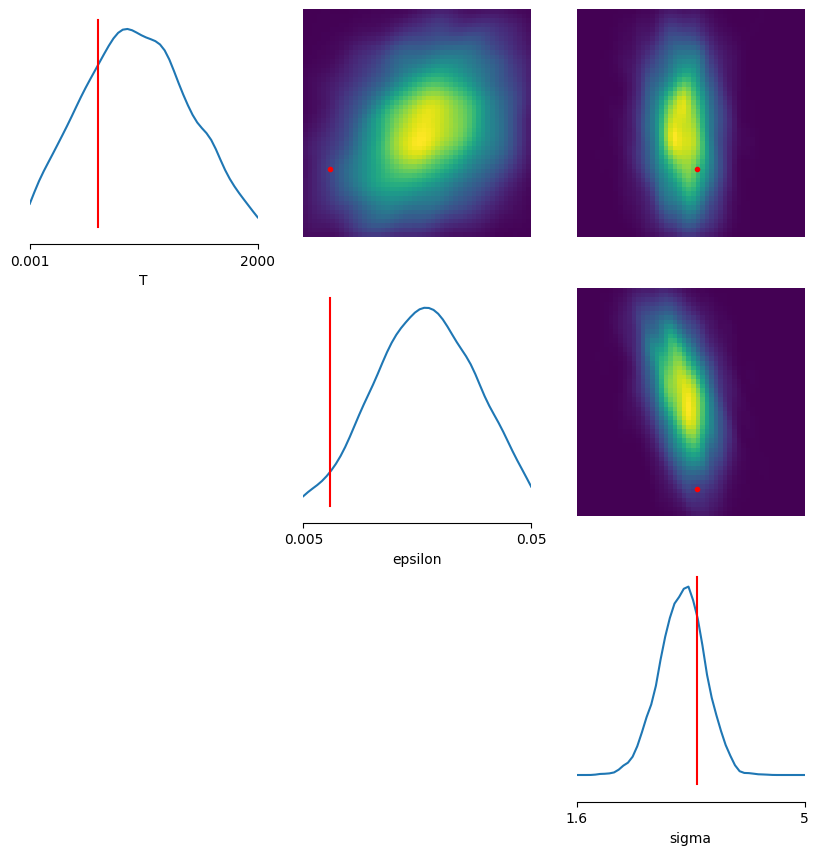

In [85]:
fig, axes = pairplot(
    theta_p,
    limits=list(zip(prior_min, prior_max)),
    ticks=list(zip(prior_min, prior_max)),
    fig_kwargs={
        "figsize": (7, 7),
        "points_offdiag": {"markersize": 6},
        "points_colors": "r",
    },
    labels=parameter_labels,
    upper="kde",
    diag="kde",
    points=theta_o,
)
plt.show()

Usando `sbi` junto con summary statistics, logramos inferir los parametros del potencial de Lennard-Jones y la temperatura del sistema sin alimentar a la red con las trayectorias completas.

La idea central es que las summary statistics incorporan conocimiento del problema y reducen mucho la dimension de la entrada. El costo es que esa compresion depende de decisiones manuales: si el resumen es pobre, la posterior tambien lo sera.

## Fijemos epsilon

In [110]:
def create_x2(theta, epsilon=0.0103):
    T, sigma = unpack_theta(theta)
    return run_md(dt, len(t), x0.copy(), T, epsilon, sigma, box_length=box_length)

In [ ]:
parameter_labels2 = ["T", "sigma"]
prior_min2 = torch.as_tensor([1e-3, 1.6])
prior_max2 = torch.as_tensor([2000.0, 5.0])
prior2 = BoxUniform(low=prior_min2, high=prior_max2)

for name, low, high in zip(parameter_labels2, prior_min2, prior_max2):
    print(f"Prior {name}: [{float(low):.4g}, {float(high):.4g}]")

Prior T: [0.001, 2000]
Prior sigma: [1.6, 5]


In [112]:
prior2.to("cpu")
prior2, num_parameters, prior_returns_numpy = process_prior(prior2)
simulate_x2 = process_simulator(create_x2, prior2, prior_returns_numpy)

In [113]:
%%time
theta_traj2, x_traj2= simulate_for_sbi(
    simulate_x2,
    prior2,
    num_simulations=n_traj_simulations,
    num_workers=workers,
)
print(theta_traj2.shape, x_traj2.shape)

100%|██████████| 2000/2000 [00:55<00:00, 35.99it/s]

torch.Size([2000, 2]) torch.Size([2000, 4000, 4])
CPU times: user 12.1 s, sys: 598 ms, total: 12.7 s
Wall time: 55.7 s


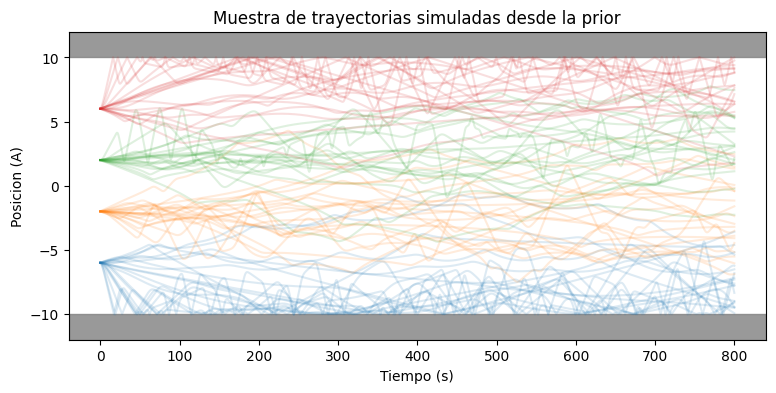

In [114]:
rng = np.random.default_rng(24)
fig, ax = plt.subplots(figsize=(9, 4))
for i, ci in zip(range(x_traj.shape[2]), mcolors.TABLEAU_COLORS):
    sample_ids = rng.choice(x_traj.shape[0], size=20, replace=False)
    for idx in sample_ids:
        ax.plot(t, x_traj[idx, :, i], color=ci, alpha=0.15)
ax.set_ylim(-box_length * 0.6, box_length * 0.6)
ax.axhspan(box_length / 2, ax.get_ylim()[1], color="gray", alpha=0.8)
ax.axhspan(ax.get_ylim()[0], -box_length / 2, color="gray", alpha=0.8)
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Posicion (A)")
ax.set_title("Muestra de trayectorias simuladas desde la prior")
plt.show()

In [129]:
def create_summary2(theta):
    x = create_x2(theta)
    return summary_from_trajectory(x)

simulate_summary2 = process_simulator(create_summary2, prior2, prior_returns_numpy)

theta2, x_summary2 = simulate_for_sbi(
    simulate_summary2,
    prior2,
    num_simulations=n_summary_simulations,
    num_workers=workers,
)
print(theta2.shape, x_summary2.shape)

100%|██████████| 2000/2000 [00:54<00:00, 36.49it/s]

torch.Size([2000, 2]) torch.Size([2000, 11])


In [140]:
train_kwargs = dict(
    training_batch_size=1024,
    learning_rate=5e-4,
    stop_after_epochs=40,
    max_num_epochs=400,
    validation_fraction=0.15,
    show_train_summary=True,
)

density_estimator2 = posterior_nn(
    "zuko_maf",
    hidden_features=64,
    num_transforms=5,
    z_score_theta="independent",
    z_score_x="independent",
)

# Entrenamos la red neuronal sobre summary statistics
prior2.to(device)
inference2 = NPE(prior=prior2, device=device, density_estimator=density_estimator2)
density_estimator2 = inference2.append_simulations(
    theta2.to(device),
    x_summary2.to(device),
    proposal=prior2,
    exclude_invalid_x=True,
).train(**train_kwargs)

 Training neural network. Epochs trained: 401
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 401
        Best validation performance: 7.3043
        -------------------------
        


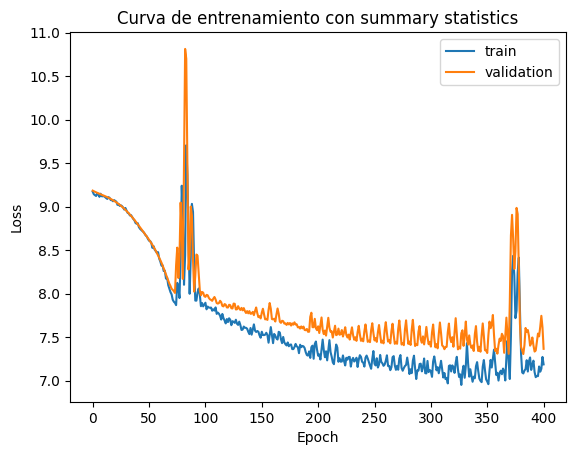

In [141]:
summary = inference2.summary
plt.plot(summary["training_loss"], label="train")
plt.plot(summary["validation_loss"], label="validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Curva de entrenamiento con summary statistics")
plt.show()

In [142]:
inference2._neural_net.to("cpu")
prior2.to("cpu")
posterior2 = inference2.build_posterior(prior=prior2)

In [158]:
theta_o2=torch.tensor([theta_o[0],theta_o[2]])
x_summary_o2 = torch.as_tensor(summary_from_trajectory(x_truth), dtype=torch.float32)
for label, value in zip(summary_labels, x_summary_o):
    print(f"{label:>14s}: {float(value):.4f}")
theta_p2 = posterior2.sample((num_posterior_draws,), x=x_summary_o2)

       dist_01: 3.8956
       dist_02: 7.8294
       dist_03: 11.7598
       dist_12: 3.9337
       dist_13: 7.8641
       dist_23: 3.9304
       picos_0: 6.0000
       picos_1: 9.0000
       picos_2: 9.0000
       picos_3: 6.0000
 energia_media: 0.0001


Drawing 5000 posterior samples for 1 observations: 5340it [00:00, 304484.61it/s]           


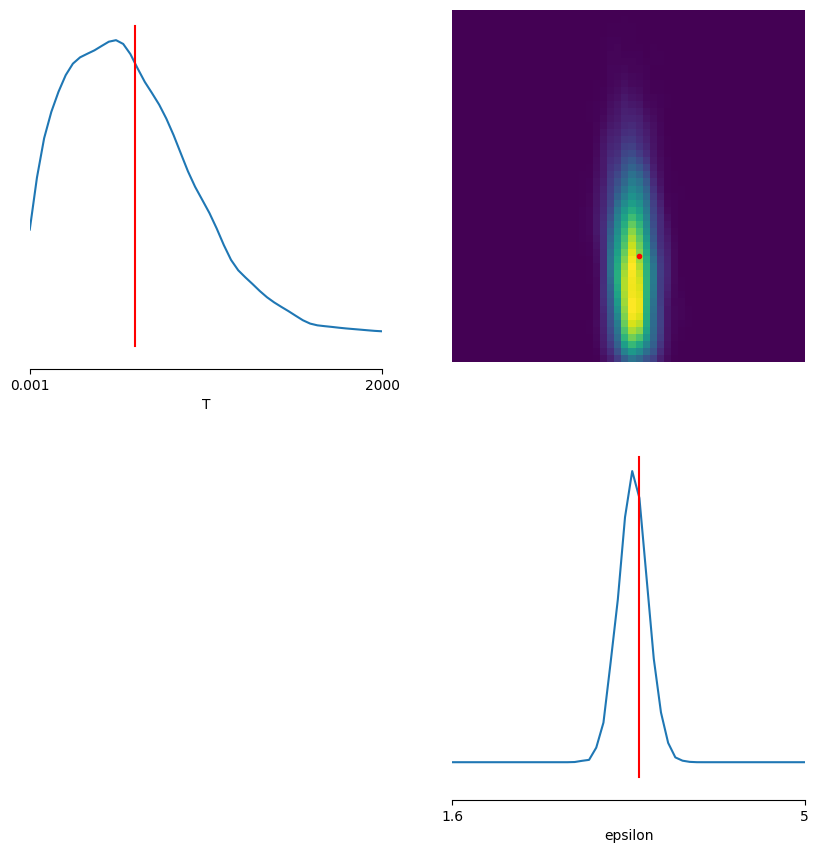

In [160]:
fig, axes = pairplot(
    theta_p2,
    limits=list(zip(prior_min2, prior_max2)),
    ticks=list(zip(prior_min2, prior_max2)),
    fig_kwargs={
        "figsize": (7, 7),
        "points_offdiag": {"markersize": 6},
        "points_colors": "r",
    },
    labels=parameter_labels,
    upper="kde",
    diag="kde",
    points=theta_o2,
)
plt.show()

## Parte 6

### Aprender summary statistics con embeddings

En lugar de construir a mano un vector resumen, tambien podemos dejar que una red neuronal aprenda una representacion compacta de las trayectorias. En `sbi`, esto se logra pasando una `embedding_net` al estimador de la posterior.

Conceptualmente, la red de embedding cumple el mismo rol que nuestras summary statistics manuales: comprimir la trayectoria cruda en un vector de menor dimension. La diferencia es que ahora esa compresion se aprende a partir de los datos simulados.

Como este enfoque trabaja con datos de mayor dimension, suele ser mas costoso. Para mantener la notebook liviana, reutilizamos las trayectorias simuladas en la Parte 4.

In [166]:
import torch.nn as nn


class TrajectoryEmbeddingNet(nn.Module):
    def __init__(self, n_atoms, embedding_dim=11):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(n_atoms, 8, kernel_size=9, stride=2, padding=4),
            nn.ReLU(),
            nn.Conv1d(8, 16, kernel_size=9, stride=2, padding=4),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(8),
        )
        self.projector = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8 * 16, 32),
            nn.ReLU(),
            nn.Linear(32, embedding_dim),
        )

    def forward(self, x):
        if x.ndim == 2:
            x = x.unsqueeze(0)
        x = x.float().transpose(1, 2)
        x = self.features(x)
        return self.projector(x)

Entrenamos ahora un segundo modelo de `sbi`, pero condicionando la posterior en el embedding aprendido de la trayectoria completa en vez del resumen manual de dimension 11.

In [167]:
theta_raw = theta_traj2.float()
x_raw = x_traj2.float()

train_kwargs_raw = dict(train_kwargs)
train_kwargs_raw.update(training_batch_size=128, max_num_epochs=150)

embedding_net = TrajectoryEmbeddingNet(n_atoms=x_raw.shape[-1], embedding_dim=11)
density_estimator_raw = posterior_nn(
    "zuko_maf",
    hidden_features=48,
    num_transforms=4,
    z_score_theta="independent",
    z_score_x="structured",
    embedding_net=embedding_net,
)

print(f"Forma de una trayectoria cruda: {tuple(x_raw.shape[1:])}")
print("El embedding aprendido tambien tendra dimension 11 para comparar con el resumen manual.")

Forma de una trayectoria cruda: (4000, 4)
El embedding aprendido tambien tendra dimension 11 para comparar con el resumen manual.


In [168]:
# Entrenamos la red neuronal con trayectorias crudas
prior2.to(device)
inference_raw = NPE(prior=prior2, device=device, density_estimator=density_estimator_raw)
density_estimator_raw = inference_raw.append_simulations(
    theta_raw.to(device),
    x_raw.to(device),
    proposal=prior2,
    exclude_invalid_x=True,
).train(**train_kwargs_raw)
summary_raw = inference_raw.summary

 Neural network successfully converged after 150 epochs.
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 150
        Best validation performance: 7.6394
        -------------------------
        


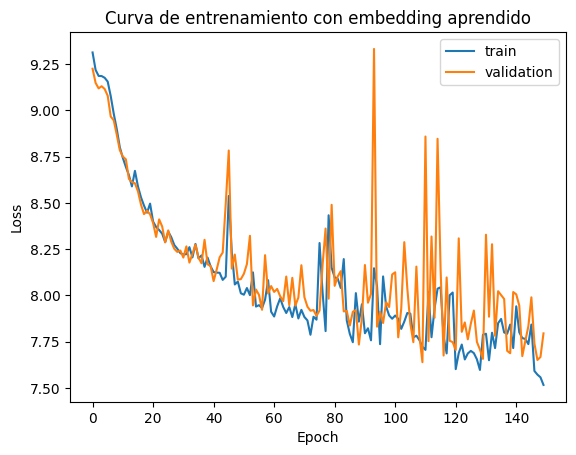

In [169]:
plt.plot(summary_raw["training_loss"], label="train")
plt.plot(summary_raw["validation_loss"], label="validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Curva de entrenamiento con embedding aprendido")
plt.show()

Para inferir la posterior sobre el dato observado, ahora pasamos la trayectoria `x_truth` completa. La red de embedding aprende automaticamente que aspectos de esa serie temporal son los mas utiles para reconstruir $p(\theta \mid x)$.

In [171]:
inference_raw._neural_net.to("cpu")
prior2.to("cpu")
posterior_raw = inference_raw.build_posterior(prior=prior2)

x_o_raw = torch.as_tensor(x_truth, dtype=torch.float32)
theta_p_raw = posterior_raw.sample((num_posterior_draws,), x=x_o_raw)

Drawing 5000 posterior samples for 1 observations: 5519it [00:00, 81986.09it/s]            


In [172]:
# En un problema real, este valor normalmente no se conoce
theta_o = torch.tensor([600.0, 0.0103, 3.4])
posterior_mean = theta_p_raw.mean(dim=0)
posterior_q05 = torch.quantile(theta_p_raw, 0.05, dim=0)
posterior_q95 = torch.quantile(theta_p_raw, 0.95, dim=0)

for name, truth, mean, q05, q95 in zip(parameter_labels, theta_o, posterior_mean, posterior_q05, posterior_q95):
    print(
        f"{name:>8s} | verdad = {float(truth):8.4f} | media posterior = {float(mean):8.4f} | IC90% = [{float(q05):8.4f}, {float(q95):8.4f}]"
    )

       T | verdad = 600.0000 | media posterior = 667.0723 | IC90% = [ 79.3349, 1434.5791]
 epsilon | verdad =   0.0103 | media posterior =   3.4839 | IC90% = [  3.0776,   3.8868]


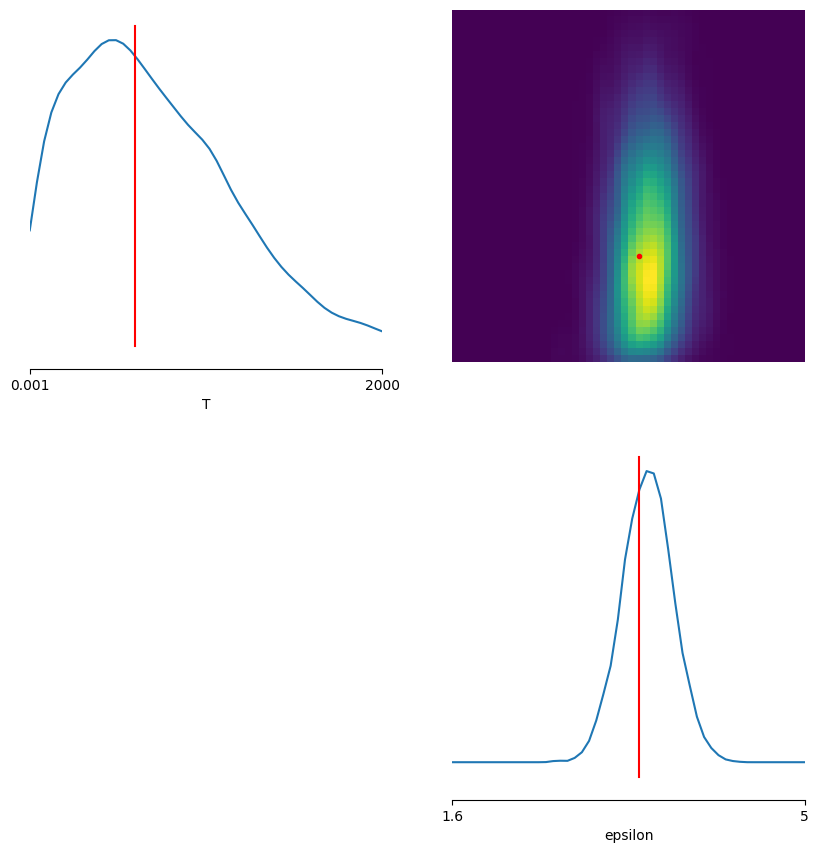

In [175]:
fig, axes = pairplot(
    theta_p_raw,
    limits=list(zip(prior_min2, prior_max2)),
    ticks=list(zip(prior_min2, prior_max2)),
    fig_kwargs={
        "figsize": (7, 7),
        "points_offdiag": {"markersize": 6},
        "points_colors": "r",
    },
    labels=parameter_labels,
    upper="kde",
    diag="kde",
    points=theta_o2,
)
plt.show()

En este segundo enfoque ya no definimos manualmente las summary statistics: la red convolucional actua como un compresor aprendido de las trayectorias.

Eso lo vuelve mas flexible, pero normalmente requiere mas capacidad de modelo, mas simulaciones y menos interpretabilidad que el enfoque con summary statistics manuales.

## Parte 7

### SNPE directamente sobre summary statistics

Hasta ahora entrenamos posteriors amortizadas: un solo modelo sirve para muchas observaciones. `SNPE` agrega una idea extra: hacer rondas secuenciales de simulacion para concentrar el presupuesto en la region del espacio de parametros que importa para una observacion concreta.

En esta seccion vamos a usar `SNPE`, pero **sin embeddings**. Es decir, la informacion que entra al metodo sera directamente el vector de summary statistics de dimension 11.

In [179]:
snpe_train_kwargs = dict(
    training_batch_size=256,
    learning_rate=3e-4,
    stop_after_epochs=15,
    max_num_epochs=150,
    validation_fraction=0.15,
    show_train_summary=True,
)

density_estimator_snpe = posterior_nn(
    "maf",
    hidden_features=48,
    # num_components=8,
    num_transforms=4,
    z_score_theta="independent",
    z_score_x="independent",
)

print("SNPE trabajara directamente con summary statistics de dimension 11.")

SNPE trabajara directamente con summary statistics de dimension 11.


En la primera ronda reutilizamos los resumenes simulados desde la prior. Eso nos da un punto de partida razonable sin repetir simulaciones ya disponibles.

In [184]:
prior2.to(device)
inference_snpe = SNPE(prior=prior2, device=device, density_estimator=density_estimator_snpe)

_ = inference_snpe.append_simulations(
    theta2.to(device),
    x_summary2.to(device),
    proposal=prior2,
    exclude_invalid_x=True,
).train(**snpe_train_kwargs)

inference_snpe._neural_net.to("cpu")
prior2.to("cpu")
posterior_round1 = inference_snpe.build_posterior(prior=prior2)
proposal_round2 = posterior_round1.set_default_x(x_summary_o)

 Neural network successfully converged after 107 epochs.
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 107
        Best validation performance: 7.1466
        -------------------------
        


Con esa propuesta centrada en el resumen observado `x_summary_o`, corremos una segunda ronda de simulaciones. Ahora `SNPE` usa parametros muestreados de la posterior aproximada de la ronda anterior, lo que vuelve mas eficiente el presupuesto de simulacion cerca del dato observado.

In [185]:
%%time
theta_round2, x_summary_round2 = simulate_for_sbi(
    simulate_summary2,
    proposal_round2,
    num_simulations=n_round2_simulations,
    num_workers=workers,
)
print(theta_round2.shape, x_summary_round2.shape)

Drawing 1000 posterior samples for 1 observations: 1071it [00:00, 207477.70it/s]           
100%|██████████| 1000/1000 [00:27<00:00, 36.35it/s]

torch.Size([1000, 2]) torch.Size([1000, 11])
CPU times: user 8.04 s, sys: 399 ms, total: 8.44 s
Wall time: 27.6 s


In [186]:
prior2.to(device)
_ = inference_snpe.append_simulations(
    theta_round2.to(device),
    x_summary_round2.to(device),
    proposal=proposal_round2,
    exclude_invalid_x=True,
).train(**snpe_train_kwargs)
summary_snpe = inference_snpe.summary

Using SNPE-C with atomic loss
 Neural network successfully converged after 17 epochs.
        -------------------------
        ||||| ROUND 2 STATS |||||:
        -------------------------
        Epochs trained: 17
        Best validation performance: 1.0500
        -------------------------
        


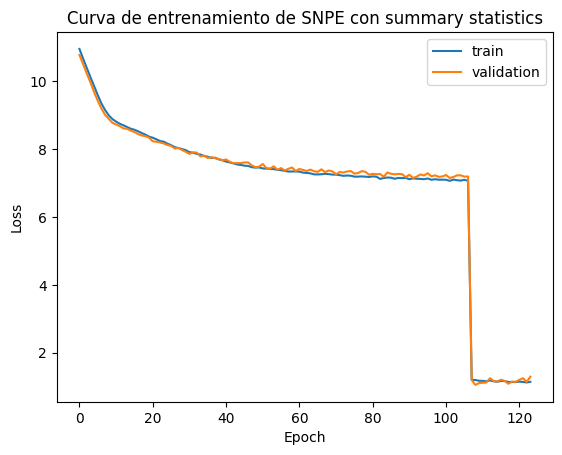

In [187]:
plt.plot(summary_snpe["training_loss"], label="train")
plt.plot(summary_snpe["validation_loss"], label="validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Curva de entrenamiento de SNPE con summary statistics")
plt.show()

In [188]:
inference_snpe._neural_net.to("cpu")
prior2.to("cpu")
posterior_snpe = inference_snpe.build_posterior(prior=prior2).set_default_x(x_summary_o)

theta_p_snpe = posterior_snpe.sample((num_posterior_draws,))

Drawing 5000 posterior samples for 1 observations: 5827it [00:00, 268143.52it/s]           


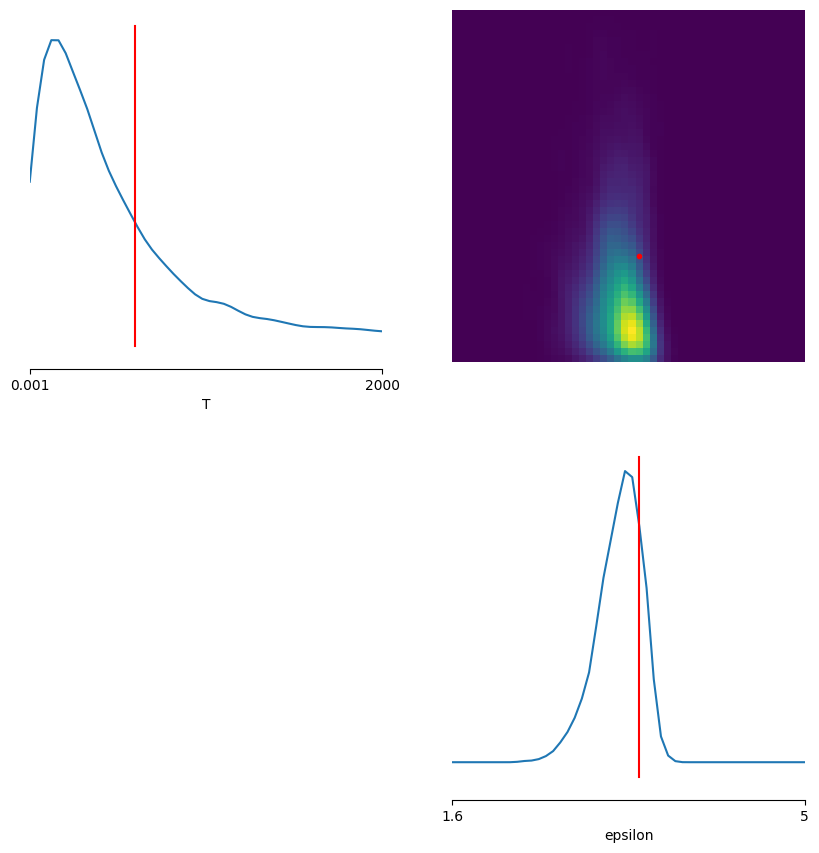

In [191]:
fig, axes = pairplot(
    theta_p_snpe,
    limits=list(zip(prior_min2, prior_max2)),
    ticks=list(zip(prior_min2, prior_max2)),
    fig_kwargs={
        "figsize": (7, 7),
        "points_offdiag": {"markersize": 6},
        "points_colors": "r",
    },
    labels=parameter_labels,
    upper="kde",
    diag="kde",
    points=theta_o2,
)
plt.show()

A diferencia del caso amortizado, esta posterior final queda especializada en la observacion resumida `x_summary_o`. Esa es justamente la ventaja de `SNPE`: dedicar nuevas simulaciones a la region del espacio de parametros que importa para este dato observado.

## Parte 8

### Diagnosticos de la calidad de la posterior

Antes de confiar en una posterior aproximada, conviene someterla a varios chequeos. Vamos a usar tres diagnosticos complementarios:

- **posterior predictive checks (PPC)** para ver si la posterior genera trayectorias parecidas a la observada `x_truth`;
- **expected coverage** para evaluar si la posterior conjunta es, en promedio, demasiado angosta o demasiado ancha;
- **simulation-based calibration (SBC)** para revisar si las marginales de cada parametro estan bien calibradas.

Los chequeos globales de calibracion se apoyan de manera natural en la posterior amortizada basada en summary statistics, porque ahi podemos generar muchos pares nuevos $(\theta, x_{summary})$ desde la prior. En cambio, el PPC sobre `x_truth` lo haremos con la posterior secuencial `posterior_snpe`, que esta especializada en la observacion real.

In [193]:
def simulate_trajectories(theta_batch):
    return torch.stack(
        [torch.as_tensor(create_x2(theta_i.cpu()), dtype=torch.float32) for theta_i in theta_batch]
    )

#### PPC sobre la observacion `x_truth`

Si la posterior capturo bien la informacion del problema, las trayectorias generadas a partir de muestras de la posterior deberian contener razonablemente a la trayectoria observada. No esperamos coincidencia exacta punto a punto, pero si una reproduccion creible de la dinamica.

Drawing 200 posterior samples for 1 observations: 258it [00:00, 82719.04it/s]            


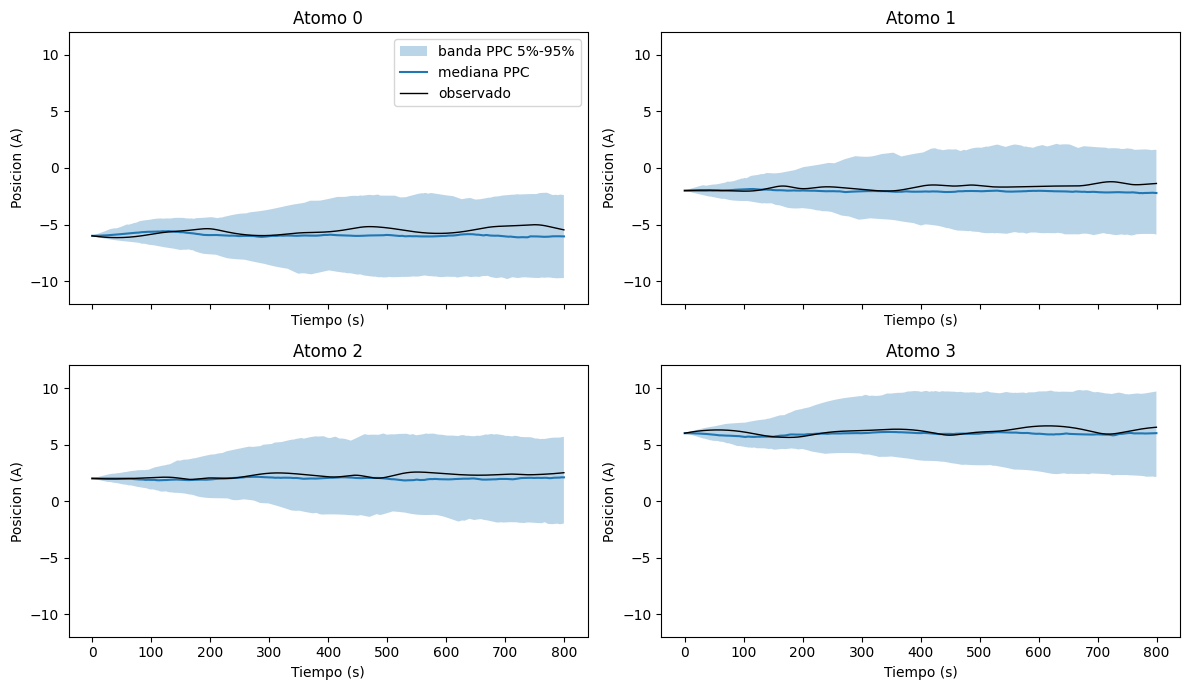

In [194]:
theta_ppc = posterior_snpe.sample((num_ppc_samples,))
x_ppc = simulate_trajectories(theta_ppc)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
axes = axes.ravel()

for atom, ax in enumerate(axes):
    low = torch.quantile(x_ppc[:, :, atom], 0.05, dim=0).numpy()
    median = torch.quantile(x_ppc[:, :, atom], 0.50, dim=0).numpy()
    high = torch.quantile(x_ppc[:, :, atom], 0.95, dim=0).numpy()

    ax.fill_between(t, low, high, alpha=0.3, label="banda PPC 5%-95%")
    ax.plot(t, median, lw=1.5, label="mediana PPC")
    ax.plot(t, x_truth[:, atom], color="k", lw=1, label="observado")
    ax.set_title(f"Atomo {atom}")
    ax.set_xlabel("Tiempo (s)")
    ax.set_ylabel("Posicion (A)")
    ax.set_ylim(-box_length * 0.6, box_length * 0.6)

axes[0].legend(loc="upper right")
plt.tight_layout()
plt.show()

#### Datos de calibracion

Para `expected coverage` y `SBC` necesitamos pares nuevos $(\theta, x_{summary})$ simulados desde la prior. Reservamos un conjunto aparte de calibracion para no mezclarlo con los datos usados en entrenamiento ni con la observacion real `x_truth`.

In [195]:
prior2.to("cpu")
theta_diag, x_summary_diag = simulate_for_sbi(
    simulate_summary2,
    prior2,
    num_simulations=num_diag_samples,
    num_workers=workers,
)
x_summary_diag = x_summary_diag.float()
print(theta_diag.shape, x_summary_diag.shape)

100%|██████████| 150/150 [00:03<00:00, 41.68it/s]

torch.Size([150, 2]) torch.Size([150, 11])


#### Expected coverage

En `sbi`, este diagnostico se implementa con `run_sbc`, pero usando como reduccion el `log_prob` de la posterior. Si la curva CDF queda por debajo de la diagonal, la posterior tiende a ser sobreconfiada; si queda por encima, tiende a ser demasiado dispersa.

Calculating ranks for 150 sbc samples.: 100%|██████████| 150/150 [00:08<00:00, 17.32it/s]


{'ks_pvals': tensor([0.4346]), 'c2st_ranks': tensor([0.5167], dtype=torch.float64), 'c2st_dap': tensor([0.5200, 0.5133], dtype=torch.float64)}


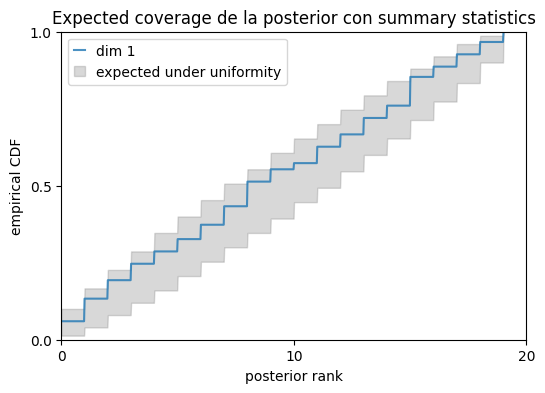

In [198]:
ranks_ec, dap_ec = run_sbc(
    theta_diag,
    x_summary_diag,
    posterior2,
    num_posterior_samples=num_posterior_samples_diag,
    reduce_fns=posterior2.log_prob,
    use_batched_sampling=False,
)
ec_stats = check_sbc(ranks_ec, theta_diag, dap_ec, num_posterior_samples_diag)
print(ec_stats)

fig, ax = sbc_rank_plot(
    ranks_ec,
    num_posterior_samples_diag,
    plot_type="cdf",
    num_bins=20,
    figsize=(6, 4),
)
ax.set_title("Expected coverage de la posterior con summary statistics")
plt.show()

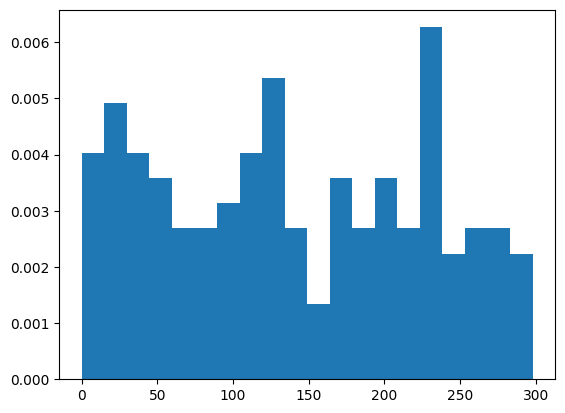

In [199]:
plt.hist(ranks_ec.cpu().numpy(), bins=20, density=True)
plt.show()

#### Simulation-based calibration (SBC)

Ahora hacemos el chequeo marginal estandar de `SBC`. Los histogramas de rangos deberian quedar, idealmente, dentro de la banda gris de uniformidad para no rechazar que las marginales estan bien calibradas.

Calculating ranks for 150 sbc samples.: 100%|██████████| 150/150 [00:00<00:00, 42576.00it/s]


{'ks_pvals': tensor([0.0015, 0.0391]), 'c2st_ranks': tensor([0.5467, 0.5000], dtype=torch.float64), 'c2st_dap': tensor([0.5600, 0.4467], dtype=torch.float64)}


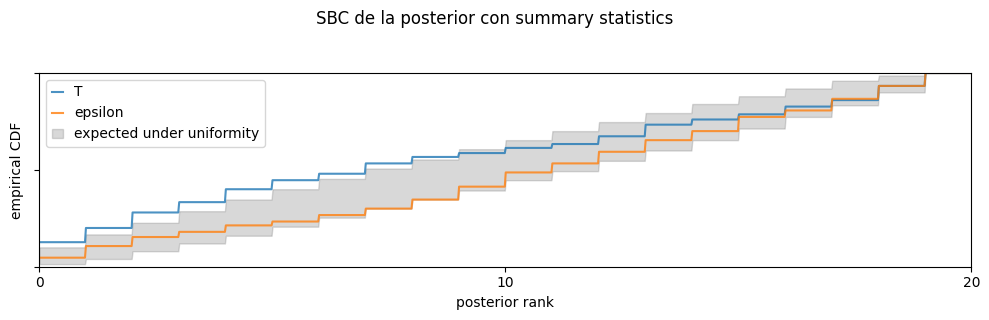

In [200]:
ranks_sbc, dap_sbc = run_sbc(
    theta_diag,
    x_summary_diag,
    posterior2,
    num_posterior_samples=num_posterior_samples_diag,
    use_batched_sampling=False,
)
sbc_stats = check_sbc(ranks_sbc, theta_diag, dap_sbc, num_posterior_samples_diag)
print(sbc_stats)

fig, ax = sbc_rank_plot(
    ranks_sbc,
    num_posterior_samples_diag,
    num_bins=20,
    figsize=(10, 3),
    parameter_labels=parameter_labels,
)
plt.suptitle("SBC de la posterior con summary statistics", y=1.05)
plt.tight_layout()
plt.show()